# Заняття 10. Інструменти та методології тестування мультиагентних систем

## 🎯 Очікуваний результат

Після цього заняття ви зможете:

1. **Розуміти** чому класичні підходи до тестування не працюють для LLM-агентів і де проходить межа між unit-тестами та evals
2. **Знати** основні метрики для оцінки генерації, retrieval-компонентів та агентних workflow
3. **Застосовувати** патерн **LLM-as-a-Judge** для автоматизації перевірок і розуміти його обмеження
4. **Імплементувати** тестування агентів у стилі `pytest` за допомогою **DeepEval**, включаючи агентні метрики
5. **Генерувати** синтетичні датасети за допомогою **Ragas** для покриття edge cases

---

## ⚙️ Підготовка середовища

Встановлюємо всі необхідні бібліотеки. Основні інструменти цієї лекції:

- **`deepeval`** — фреймворк для тестування LLM-додатків у стилі pytest
- **`ragas`** — фреймворк для оцінки RAG-систем та генерації синтетичних тестових даних
- **`langchain` + `langchain-openai`** — для побудови демонстраційного RAG-агента, якого ми будемо тестувати

In [1]:
# Install required packages (strict versions for reproducibility)
# NOTE: Restart runtime/kernel after installation

!pip install -q \
    deepeval==3.9.5 \
    ragas==0.4.3 \
    langchain==1.2.15 \
    langchain-openai==1.1.12 \
    langchain-community==0.4.1 \
    faiss-cpu==1.13.2 \
    tiktoken==0.12.0 \
    pandas==2.2.3


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Environment setup and API key configuration
import os
import json
import warnings
warnings.filterwarnings("ignore")

from getpass import getpass

if not os.getenv("OPENAI_API_KEY"):
    key = getpass("Enter OpenAI API Key: ").strip()
    # Remove invisible non-ASCII characters that can appear from copy-paste
    os.environ["OPENAI_API_KEY"] = key.encode("ascii", errors="ignore").decode()

print(f"API key loaded (prefix: {os.environ["OPENAI_API_KEY"][:8]}...)")

Enter OpenAI API Key: ········


---

## Блок 0. Класичні метрики класифікації — коротке нагадування

Перш ніж перейти до специфічних метрик для LLM-систем, пригадаємо базові метрики, на яких побудована вся оцінка якості в ML. Ці концепції з'являтимуться далі в контексті evaluation фреймворків.

### Confusion Matrix

Основа всіх класифікаційних метрик — **confusion matrix**:

| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | TP (True Positive) | FN (False Negative) |
| **Actual Negative** | FP (False Positive) | TN (True Negative) |

### Основні метрики

**Accuracy** — частка правильних передбачень серед усіх:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Проблема: на незбалансованих даних accuracy вводить в оману. Якщо 95% прикладів — клас A, модель що завжди відповідає "A" матиме accuracy 95%.

**Precision** — серед усіх, кого ми назвали positive, скільки дійсно positive:

$$\text{Precision} = \frac{TP}{TP + FP}$$

Важлива, коли **ціна False Positive висока** (наприклад, спам-фільтр: краще пропустити спам, ніж загубити важливий лист).

**Recall (Sensitivity)** — серед усіх дійсно positive, скільки ми знайшли:

$$\text{Recall} = \frac{TP}{TP + FN}$$

Важлива, коли **ціна False Negative висока** (наприклад, медична діагностика: краще зайвий раз перевірити, ніж пропустити хворобу).

**F1-Score** — гармонічне середнє Precision та Recall:

$$\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

Корисна як єдине число, що балансує обидві метрики. Якщо одна з них дуже низька — F1 теж буде низьким.

### Як це стосується LLM-evaluation?

У контексті тестування агентних систем ці метрики з'являються в кількох місцях:

| Класична метрика | Аналог в LLM-evaluation | Приклад |
|---|---|---|
| **Precision** | Context Precision | З усіх знайдених документів — скільки дійсно релевантних? |
| **Recall** | Context Recall | З усіх потрібних документів — скільки знайшов retriever? |
| **F1** | Factual Correctness | Баланс між повнотою та точністю фактів у відповіді |
| **Accuracy** | Task Completion / Tool Correctness | Чи правильно агент виконав задачу або обрав інструмент? |

> Важлива відмінність: класичні метрики працюють з бінарними або категоріальними мітками. В LLM-evaluation оцінки часто **continuous (0.0–1.0)** і визначаються іншою LLM (LLM-as-a-Judge), а не точним порівнянням.

In [3]:
# Quick demo: classification metrics on a toy example
# This shows the intuition before we move to LLM-specific metrics

from collections import Counter

# Simulated binary classification results
y_true = [1, 1, 1, 1, 0, 0, 0, 0, 1, 1]  # actual labels
y_pred = [1, 1, 0, 1, 0, 1, 0, 0, 1, 0]   # predicted labels

# Calculate confusion matrix components
tp = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1)  # True Positive
fp = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1)  # False Positive
fn = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0)  # False Negative
tn = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 0)  # True Negative

accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("Confusion Matrix:")
print(f"  TP={tp}  FN={fn}")
print(f"  FP={fp}  TN={tn}")
print()
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f} (of all predicted positive, how many are correct)")
print(f"Recall:    {recall:.2f} (of all actual positive, how many did we find)")
print(f"F1-Score:  {f1:.2f} (harmonic mean of precision and recall)")

Confusion Matrix:
  TP=4  FN=2
  FP=1  TN=3

Accuracy:  0.70
Precision: 0.80 (of all predicted positive, how many are correct)
Recall:    0.67 (of all actual positive, how many did we find)
F1-Score:  0.73 (harmonic mean of precision and recall)


---

## Блок 1. Проблема тестування недетермінованих систем

### 1.1 Зсув парадигми: від `assert ==` до семантичної оцінки

У класичному software engineering тестування будується на простому принципі: подаємо вхідні дані, отримуємо вихід, порівнюємо з очікуваним результатом.

```python
# Класичний unit-test — детермінований
def test_addition():
    assert add(2, 3) == 5  # Завжди працює ✅
```

З LLM все інакше. Та сама модель із тими самими параметрами на той самий prompt дає **різні відповіді** при кожному виклику. Це не баг — це фундаментальна властивість імовірнісної генерації.

> 🔑 **Головне:** Тестування LLM-систем — це не перевірка "правильності", а оцінка "якості в допустимих межах" (scoring 0–1 замість pass/fail).

In [4]:
# Demonstration: LLM non-determinism
# The same prompt produces different outputs each time

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0.0, max_tokens=150)
prompt = "Name three advantages of Python for Data Science. Answer briefly, in one sentence."

print("=" * 70)
print(f"Prompt: {prompt}")
print("=" * 70)

responses = []
for i in range(3):
    result = llm.invoke(prompt)
    text = result.content.strip()
    responses.append(text)
    print(f"\nRun {i+1}: {text}")

# Classic assertion would FAIL
print("\n" + "=" * 70)
print("🔴 assert responses[0] == responses[1]  →  FAILS!")
print(f"   Response 1: {responses[0][:60]}...")
print(f"   Response 2: {responses[1][:60]}...")
print("\n💡 We need a different approach: semantic evaluation instead of exact match")

Prompt: Name three advantages of Python for Data Science. Answer briefly, in one sentence.

Run 1: Python is popular for Data Science because it has a simple syntax, a rich ecosystem of libraries like NumPy and pandas, and strong support for data visualization and machine learning.

Run 2: Python is popular for data science because it is easy to learn, has powerful libraries like NumPy/pandas/scikit-learn, and supports quick data analysis and visualization.

Run 3: Python is popular for data science because it has a simple syntax, a rich ecosystem of libraries like NumPy and pandas, and strong support for data visualization and machine learning.

🔴 assert responses[0] == responses[1]  →  FAILS!
   Response 1: Python is popular for Data Science because it has a simple s...
   Response 2: Python is popular for data science because it is easy to lea...

💡 We need a different approach: semantic evaluation instead of exact match


### 1.2 Анатомія помилок агентних систем

В агентних системах помилки виникають на кількох рівнях:

| Тип помилки | Опис | Приклад                                                                                   |
|---|---|-------------------------------------------------------------------------------------------|
| **Галюцинації** | Модель генерує факти, яких немає в наданому контексті | RAG-агент "додумує" дату, якої немає в документі                                          |
| **Втрата контексту** | При передачі задачі між агентами губляться деталі | Planner вказав "бюджет до 1000$", але Executor не врахував                                |
| **Tool calling збої** | Невірне ім'я інструменту, пошкоджений JSON, неправильні аргументи | `search_flights(origin="Warsaw")` замість `search_flights(origin="WAW", destination="LHR")` |
| **"Тихі" помилки** | Агент відповідає впевнено, але неправильно | Найнебезпечніший тип — важко відловити без evals                                          |

### 1.3 Два рівні тестування агентів

Тестування LLM-систем розділяється на два принципово різних типи:

1. **Unit-тестування (детерміноване)** — тестуємо код навколо LLM: парсинг JSON, routing logic, валідація схем, вибір інструментів. Тут класичний `pytest` працює відмінно.

2. **Evals (LLM-based оцінка)** — оцінюємо семантичну якість: чи релевантна відповідь? чи є галюцинації? чи агент досяг цілі? Тут потрібен **LLM-as-a-Judge**.

> 🔑 **Практичне правило:** Тестуйте детерміновані частини звичайним pytest. Для недетермінованих — використовуйте LLM-as-a-Judge через спеціалізовані фреймворки (DeepEval, Ragas).

---

## Блок 2. Метрики якості агентних систем

Різні компоненти мультиагентної системи потребують різних метрик. Розберемо кожну категорію.

### 2.1 Метрики генерації (Generation Quality)

Ці метрики оцінюють якість тексту, що генерує LLM:

- **Answer Correctness / Factual Correctness** — чи фактично правильна відповідь у порівнянні з reference answer. Це **reference-based** метрика (потребує "золоту" відповідь).

- **Answer Relevancy** — чи відповідь дійсно адресує запитання, без "води" та нерелевантних деталей. Це **referenceless** метрика.

- **Hallucination** — чи містить відповідь твердження, що **суперечать** наданим даним. В DeepEval та Ragas ця метрика (і Faithfulness) перевіряє саме суперечності, а не відсутність підтвердження — це важлива відмінність (див. Блок 4.2).

### 2.2 Метрики RAG-компонентів

Для RAG-систем оцінюємо retriever та generator окремо:

- **Faithfulness** — чи відповідь **не суперечить** retrieval context. Метрика Generator. Увага: в поточних реалізаціях (DeepEval, Ragas) ця метрика перевіряє лише відсутність суперечностей, а не повну обґрунтованість. Для строгої перевірки "чи кожне твердження підтверджено контекстом" потрібна кастомна метрика (Groundedness).

- **Context Precision** — чи релевантні документи ранжуються вище за нерелевантні. Метрика Retriever. Якщо низький → retriever знаходить документи, але "хороші" губляться серед "поганих".

- **Context Recall** — чи знайдено **все** необхідне для повної відповіді. Метрика Retriever. Якщо низький → retriever пропускає важливі документи.

### 2.3 Метрики агентних систем (Agent-specific)

Для мультиагентних систем — спеціалізовані метрики:

| Метрика | Що оцінює | Рівень | Фреймворк |
|---|---|---|---|
| **Task Completion** | Чи досяг агент цілі користувача | End-to-end | DeepEval |
| **Tool Correctness** | Чи правильні інструменти викликано | Component | DeepEval |
| **Argument Correctness** | Чи правильні параметри передано в tool | Component | DeepEval |
| **Plan Quality** | Чи план агента логічний та повний | Reasoning | DeepEval |
| **Plan Adherence** | Чи агент дотримується свого плану | Reasoning | DeepEval |
| **Step Efficiency** | Чи не робить агент зайвих кроків | Execution | DeepEval |
| **Agent Goal Accuracy** | Чи досягнуто мету (binary: 0/1) | End-to-end | Ragas |
| **Tool Call Accuracy** | Чи правильно обрано та викликано інструменти | Component | Ragas |
| **Topic Adherence** | Чи агент залишається в рамках дозволених доменів | Safety | Ragas |

### Як це працює під капотом?

Агентні метрики використовують **три різних підходи** до обчислення:

**1. Детерміністичне порівняння (exact match)**
Найпростіший підхід: порівнюємо фактичні tool calls з очікуваними напряму — ім'я функції, параметри, результат. Так працює, наприклад, **Tool Call Accuracy** (Ragas): якщо агент викликав `search_flights(origin="WAW")`, а очікувалось `search_flights(origin="WAW")` — це exact match, score = 1.0. Жодного LLM-виклику, повна відтворюваність, але й повна "жорсткість" — будь-яка розбіжність у параметрах = 0.

**2. LLM-as-a-Judge**
Більшість складних метрик працюють саме так: фреймворк формує спеціальний prompt і відправляє його до LLM-судді. Наприклад:
- **Task Completion** (DeepEval): з трейсу агента LLM витягує задачу та результат, потім оцінює наскільки результат відповідає задачі (AlignmentScore)
- **Agent Goal Accuracy** (Ragas): LLM аналізує весь діалог, визначає мету користувача та чи була вона досягнута (binary: 0 або 1)
- **Topic Adherence** (Ragas): LLM класифікує чи відповіді агента залишаються в рамках дозволених тем, потім рахується precision/recall

**3. Гібридний підхід**
**Tool Correctness** (DeepEval) поєднує обидва: спочатку детерміністично рахує `correct_tools / total_tools`, а якщо надано список всіх доступних інструментів — додатково просить LLM оцінити, чи був вибір оптимальним. Фінальний score = min(deterministic, llm).

> Саме тому агентні метрики повільніші за класичні ML-метрики: кожне обчислення потребує 1-3 додаткових LLM-викликів. Це також означає, що результати **недетерміновані** — один і той самий тест-кейс може отримати різний score при повторному запуску.

### 2.4 Reference-based vs. Referenceless

Критичне розрізнення для практики:

- **Reference-based** метрики потребують "золоту відповідь" (ground truth): Correctness, Context Recall, Tool Correctness. Використовуються в **pre-deployment тестуванні** з Golden Dataset.

- **Referenceless** метрики працюють без ground truth: Faithfulness, Answer Relevancy, Task Completion. Критичні для **production monitoring** — в реальному часі golden answer немає.

> 🔑 **На практиці:** Для pre-deployment тестування використовуйте reference-based метрики з Golden Dataset. Для production monitoring — referenceless. Ідеально мати обидва.

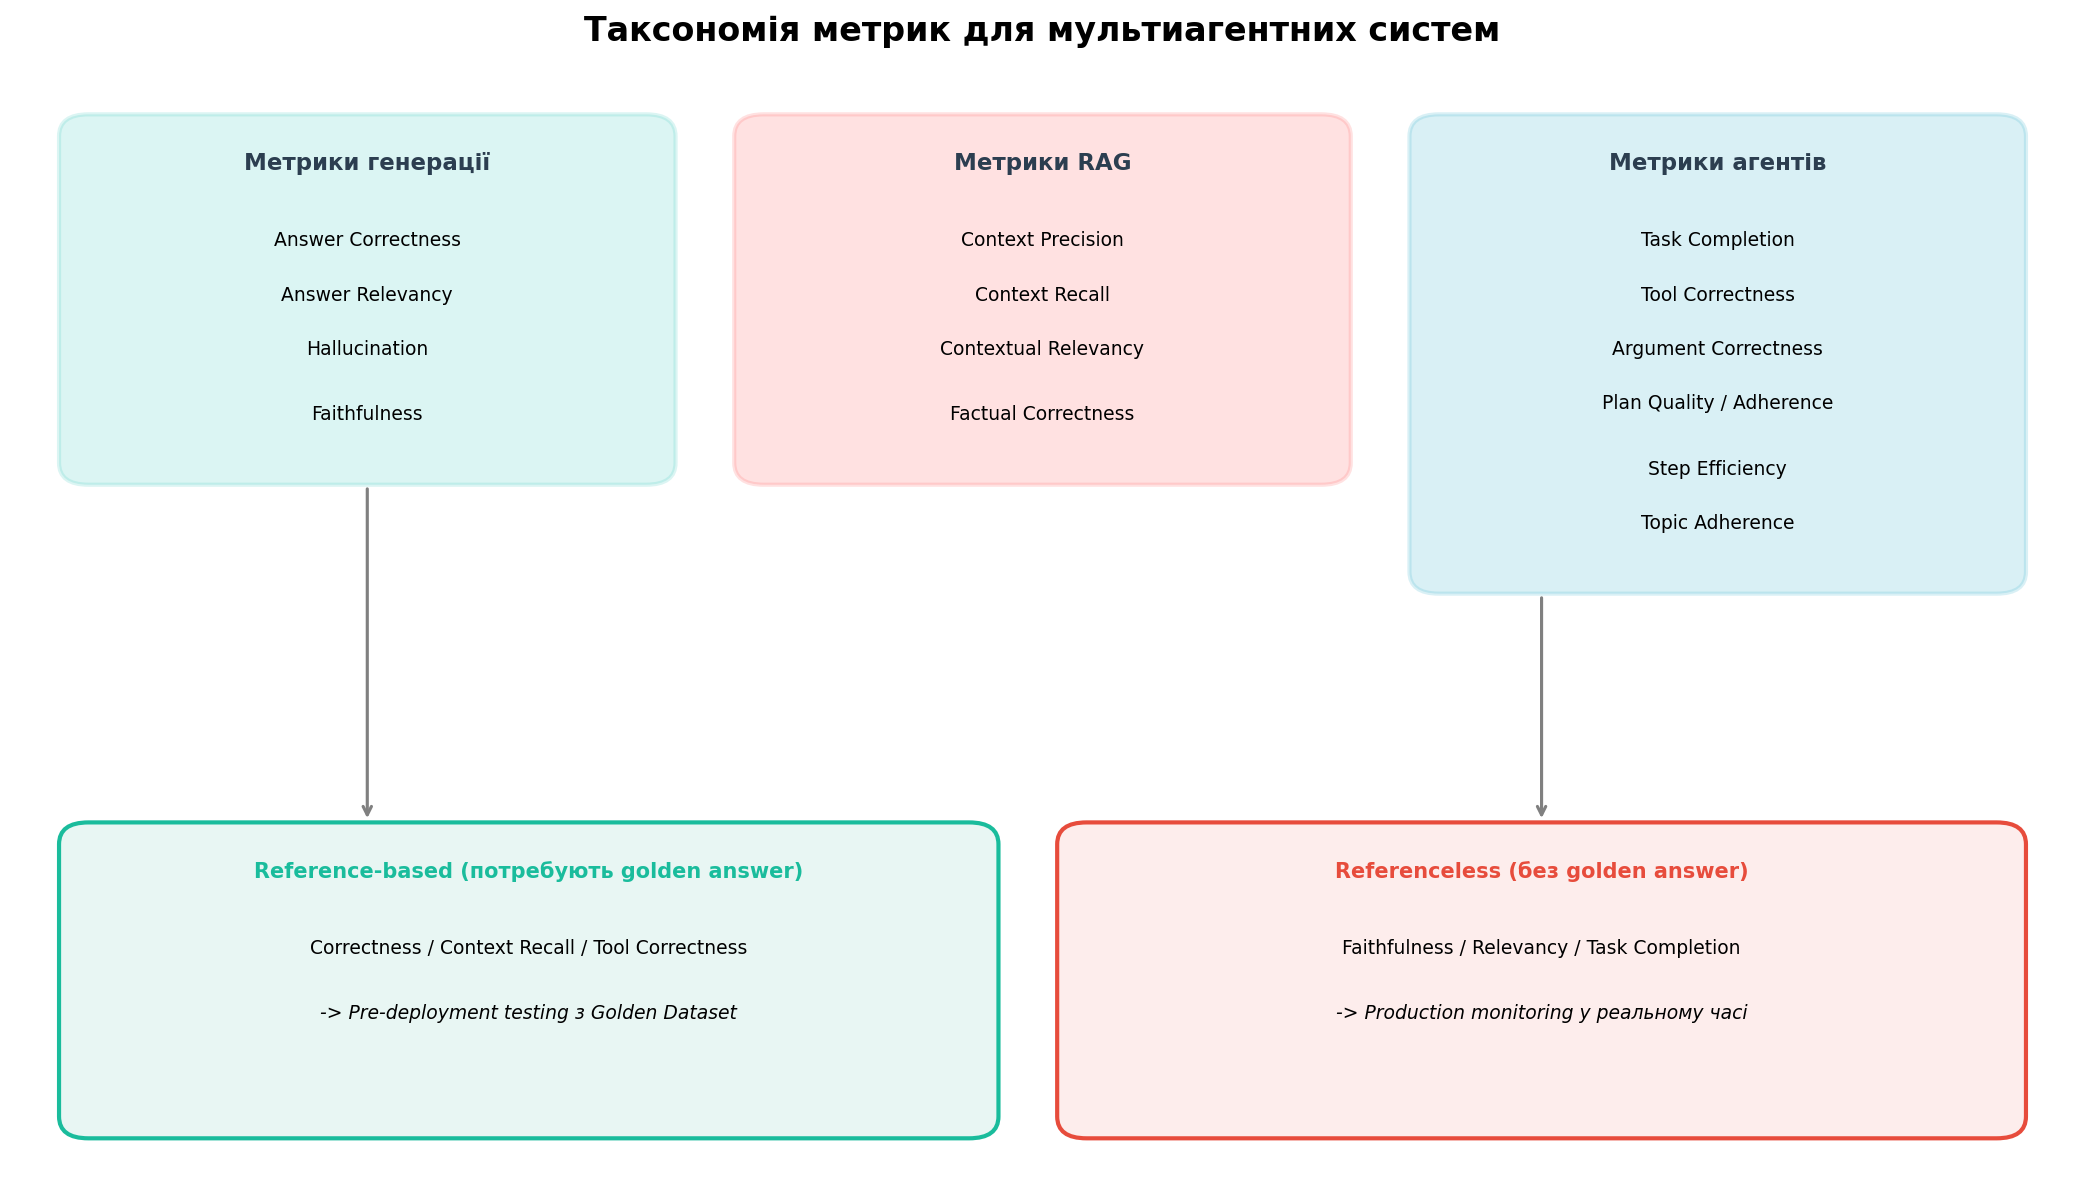

In [5]:
# Metrics taxonomy for multi-agent systems
from IPython.display import Image

Image("images/metrics_taxonomy.png")

---

## Блок 3. Патерн LLM-as-a-Judge

### 3.1 Концепція: модель оцінює модель

**LLM-as-a-Judge** — це підхід, коли ми використовуємо потужну мовну модель (наприклад, GPT-5.4) для оцінки відповідей іншої моделі або агентної системи.

Чому це працює: сучасні LLM досягають приблизно **80% agreement** з людськими оцінками — це рівень узгодженості між самими людськими анотаторами.

Два основних режими:
- **Scoring (пряме оцінювання):** Модель ставить оцінку 0–1 (або 1–5) одній відповіді за визначеними критеріями.
- **Pairwise comparison:** Модель порівнює дві відповіді та обирає кращу.

### 3.2 Архітектура evaluation prompt

Якісний evaluation prompt складається з:
1. **Роль судді** — чітко визначити, що модель є експертним оцінювачем
2. **Критерії оцінювання** — що саме оцінюємо (точність, релевантність, повнота)
3. **Шкала** — від 0 до 1, або рубрики (rubrics) з описом кожного бала
4. **Вимога reasoning ПЕРЕД score**!

> 🔑 **Важливо:** Завжди вимагайте від судді пояснити **reasoning перед** тим, як дати оцінку. Без цього модель спочатку генерує число "навмання", а потім раціоналізує його.

In [6]:
# Implementing LLM-as-a-Judge from scratch
# This demonstrates the core pattern before we use frameworks

from langchain_openai import ChatOpenAI

judge_llm = ChatOpenAI(
    model="gpt-5.4-mini",
    temperature=0.0,
).bind(response_format={"type": "json_object"})


def llm_judge(question: str, answer: str, reference: str, criteria: str = "correctness") -> dict:
    """
    Simple LLM-as-a-Judge implementation.
    Returns: {"score": float, "reasoning": str}
    """
    evaluation_prompt = f"""You are an expert evaluator. Assess the quality of the given answer.

EVALUATION CRITERIA: {criteria}
- Score 1.0: Perfect — fully correct, complete, and relevant
- Score 0.7-0.9: Good — mostly correct with minor issues
- Score 0.4-0.6: Partial — some correct elements but significant gaps
- Score 0.1-0.3: Poor — mostly incorrect or irrelevant
- Score 0.0: Completely wrong or off-topic

QUESTION: {question}

REFERENCE ANSWER: {reference}

ANSWER TO EVALUATE: {answer}

IMPORTANT: First explain your reasoning step by step, then give a score.
Respond in this exact JSON format:
{{"reasoning": "your detailed reasoning here", "score": 0.0}}"""

    response = judge_llm.invoke(evaluation_prompt)
    result = json.loads(response.content)
    return result


# --- Test with a good answer ---
result_good = llm_judge(
    question="What is RAG?",
    answer=(
        "RAG (Retrieval-Augmented Generation) is an approach that combines "
        "retrieving relevant documents with text generation by a model to "
        "reduce hallucinations and provide up-to-date information."
    ),
    reference=(
        "RAG is an architecture that augments LLMs with external knowledge "
        "by retrieving relevant documents before generating a response."
    ),
)
print("Good answer evaluation:")
print(f"   Score: {result_good['score']}")
print(f"   Reasoning: {result_good['reasoning'][:200]}...")

print()

# --- Test with a hallucinated answer ---
result_bad = llm_judge(
    question="What is RAG?",
    answer=(
        "RAG is a neural network developed by Google in 2018 specifically "
        "for text translation. It is based on the RNN architecture."
    ),
    reference=(
        "RAG is an architecture that augments LLMs with external knowledge "
        "by retrieving relevant documents before generating a response."
    ),
)
print("Hallucinated answer evaluation:")
print(f"   Score: {result_bad['score']}")
print(f"   Reasoning: {result_bad['reasoning'][:200]}...")

Good answer evaluation:
   Score: 0.95
   Reasoning: The answer correctly expands RAG as Retrieval-Augmented Generation and explains the core idea: combining retrieval of relevant documents with generation by a model. This matches the reference definiti...

Hallucinated answer evaluation:
   Score: 0.0
   Reasoning: The answer is incorrect. RAG stands for Retrieval-Augmented Generation, an approach that enhances language models by retrieving relevant external information before generating a response. The provided...


### 3.3 Упередженість LLM-суддів та методи їх пом'якшення

LLM-as-a-Judge — потужний інструмент, але він має системні упередженості.

#### Position Bias
Модель надає перевагу відповіді на певній **позиції** (зазвичай першій) — незалежно від її якості. За різними дослідженнями, це трапляється у 60–75% випадків.

**Рішення — порівняти двічі, поміняти місцями:**
1. Порівнюємо: `[resp_1, resp_2]` — хто виграв?
2. Міняємо місцями: `[resp_2, resp_1]` — хто виграв тепер?
3. Якщо та сама відповідь виграє в обох запусках — це справжній переможець. Якщо виграє та сама **позиція** — це position bias.

#### Self-Enhancement / Family Bias
LLM-судді вище оцінюють **власні** відповіді та відповіді моделей тієї ж "сім'ї" (family bias). Дослідження (Wataoka et al., 2024) пов'язує це з **perplexity**: моделі надають перевагу текстам з нижчою perplexity — тобто тим, що "знайоміші" для них.

**Рішення:** Використовувати суддю **іншого вендора**, ніж target система.

#### Verbosity Bias
Довші відповіді отримують вищі оцінки незалежно від якості.

**Рішення:** Явна інструкція в промпті: "Do NOT consider response length in your evaluation."

> **Порада:** Найнадійніший підхід — **LLM-as-a-Jury**: 2-3 різні моделі як судді + консенсус. Дорожче, але надійніше.

In [7]:
# Demonstration: Position Bias in LLM-as-a-Judge

from langchain_openai import ChatOpenAI

judge = ChatOpenAI(model="gpt-5.4-mini", temperature=0.0, max_tokens=5)

JUDGE_PROMPT = """Compare two responses to the question. Which is better?

Question: {question}
Response A: {a}
Response B: {b}

Reply with ONLY: A, B, or tie."""

question = "What is prompt engineering?"
resp_1 = "Prompt engineering is the process of creating and optimizing queries to language models."
resp_2 = "Prompt engineering is the discipline of designing LLM instructions, including few-shot and chain-of-thought."

# Run 1: resp_1 = A, resp_2 = B
run1 = judge.invoke(JUDGE_PROMPT.format(question=question, a=resp_1, b=resp_2)).content.strip()

# Run 2: swap positions
run2 = judge.invoke(JUDGE_PROMPT.format(question=question, a=resp_2, b=resp_1)).content.strip()

print(f"Run 1 (resp_1=A, resp_2=B): winner = {run1}")
print(f"Run 2 (resp_2=A, resp_1=B): winner = {run2}")
print()

# Interpretation:
# run1=A, run2=B  ->  resp_1 wins both times (consistent)
# run1=B, run2=A  ->  resp_2 wins both times (consistent)
# run1=A, run2=A  ->  position A always wins (bias!)
# run1=B, run2=B  ->  position B always wins (bias!)
if run1 != run2:
    same_resp_wins = "resp_1" if run1 == "A" else "resp_2"
    print(f"Consistent: {same_resp_wins} wins regardless of position")
else:
    print(f"Position bias detected: judge always picks position {run1}")

Run 1 (resp_1=A, resp_2=B): winner = B
Run 2 (resp_2=A, resp_1=B): winner = B

Position bias detected: judge always picks position B


---

## Блок 4. Практика: DeepEval — тестування LLM-систем у стилі pytest

**DeepEval** — це open-source фреймворк для тестування LLM-додатків. Він працює як `pytest`, але спеціалізований для LLM: замість `assertEqual` використовує LLM-as-a-Judge метрики, де кожен score лежить у діапазоні 0–1.

Основні переваги:
- Знайомий pytest-style API
- 50+ вбудованих метрик (RAG, agents, chatbots)
- Підтримка OpenAI, Anthropic, Ollama, Azure
- Інтеграція з CI/CD (`deepeval test run`)
- Трейсинг агентів через декоратор `@observe`

### 4.1 Структура тест-кейсу

В DeepEval кожен тест — це `LLMTestCase` з полями:

| Поле | Обов'язкове | Опис |
|---|---|---|
| `input` | ✅ | Вхідний запит користувача |
| `actual_output` | ✅ | Реальна відповідь вашого LLM |
| `expected_output` | ❌ | Еталонна (golden) відповідь |
| `retrieval_context` | ❌ | Знайдені документи (для RAG) |
| `tools_called` | ❌ | Викликані інструменти (для агентів) |
| `expected_tools` | ❌ | Очікувані інструменти (для агентів) |

У прикладі нижче використовуються дві метрики:

**AnswerRelevancyMetric** — перевіряє, чи відповідь стосується запитання. Під капотом:
1. LLM генерує N запитань, на які `actual_output` міг би бути відповіддю
2. Кожне згенероване запитання порівнюється з оригінальним `input` через cosine similarity embeddings
3. Score = середнє значення цих similarities

Це **referenceless** метрика — `expected_output` не потрібен.

**GEval** — універсальна метрика, де ви самі описуєте критерій оцінки. Під капотом:
1. DeepEval формує промпт з вашими `criteria` або `evaluation_steps`
2. LLM-суддя оцінює `actual_output` за шкалою 1–10 з chain-of-thought reasoning
3. Цей процес повторюється кілька разів, фінальний score = нормалізоване середнє (0–1)

Може бути як reference-based, так і referenceless — залежить від того, які `evaluation_params` ви передасте.

In [8]:
from deepeval import evaluate
from deepeval.test_case import LLMTestCase
from deepeval.metrics import AnswerRelevancyMetric, GEval
from deepeval.test_case import LLMTestCaseParams

# --- Create a simple test case ---
test_case = LLMTestCase(
    input="What is a multi-agent system?",
    actual_output=(
        "A multi-agent system (MAS) is a system composed of multiple "
        "autonomous agents that interact with each other to achieve common "
        "or individual goals. Each agent has its own role, set of tools, "
        "and ability to make decisions."
    ),
    expected_output=(
        "A multi-agent system is an architecture where multiple AI agents "
        "with different roles cooperate or compete to accomplish complex tasks."
    ),
)

# --- Define metrics ---
# 1. Answer Relevancy (referenceless -- doesn't need expected_output)
relevancy_metric = AnswerRelevancyMetric(
    threshold=0.7,
    model="gpt-5.4-mini",
)

# 2. GEval -- custom correctness metric (reference-based)
correctness_metric = GEval(
    name="Correctness",
    criteria="Determine whether the actual output is factually correct based on the expected output.",
    evaluation_steps=[
        "Check whether the facts in 'actual output' contradict any facts in 'expected output'",
        "Heavily penalize omission of critical details",
        "Vague language or different wording of the same idea is OK",
    ],
    evaluation_params=[
        LLMTestCaseParams.INPUT,
        LLMTestCaseParams.ACTUAL_OUTPUT,
        LLMTestCaseParams.EXPECTED_OUTPUT,
    ],
    model="gpt-5.4-mini",
    threshold=0.7,
)

# --- Run evaluation ---
print("Running DeepEval evaluation...")
print("(This makes LLM API calls -- may take 10-20 seconds)\n")

results = evaluate(
    test_cases=[test_case],
    metrics=[relevancy_metric, correctness_metric],
)

Running DeepEval evaluation...
(This makes LLM API calls -- may take 10-20 seconds)



✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-5.4-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Correctness [GEval] Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

Output()



Metrics Summary

  - ✅ Answer Relevancy (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-5.4-mini, reason: The score is 1.00 because the response directly and fully addresses the question with no irrelevant statements. It explains the concept clearly and stays focused on what a multi-agent system is., error: None)
  - ✅ Correctness [GEval] (score: 0.9, threshold: 0.7, strict: False, evaluation model: gpt-5.4-mini, reason: The actual output matches the expected definition closely: it describes a multi-agent system as multiple autonomous agents interacting to achieve goals, which aligns with the idea of agents with different roles cooperating or competing on complex tasks. There is no contradiction, and it adds acceptable extra detail about autonomy and decision-making. It only omits the explicit mention of cooperation/competition and complex tasks, but the core concept is present., error: None)

For test case:

  - input: What is a multi-agent system?
  - actual outpu

⚠ WARNING: No hyperparameters logged.
» ]8;id=700228;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 7.62s | token cost: None)
» Test Results (1 total tests):
   » Pass Rate: 100.0% | Passed: 1 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

### 4.2 Метрики RAG: Faithfulness

Для RAG-систем критично перевіряти: чи відповідь базується **виключно** на retrieval context?

**FaithfulnessMetric** (DeepEval) працює так:
1. LLM розбиває `actual_output` на окремі **твердження** (claims)
2. Для кожного LLM перевіряє: чи **суперечить** воно `retrieval_context`?
3. Score = частка тверджень без суперечностей

**Важливий нюанс:** ця метрика ловить лише **прямі суперечності** з контекстом. Якщо модель вигадує факти, яких немає в контексті, але які й не суперечать йому — FaithfulnessMetric вважатиме їх faithful (score = 1.0).

Для строгої перевірки **groundedness** (чи кожне твердження підкріплене контекстом) потрібна кастомна GEval метрика — це показано нижче.

In [9]:
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from deepeval.metrics import FaithfulnessMetric, GEval

# Context: retrieved documents
retrieval_context = [
    "Python was created by Guido van Rossum and first released in 1991. "
    "Python supports multiple programming paradigms, including procedural, "
    "object-oriented, and functional programming.",

    "Python is widely used in Data Science thanks to libraries like "
    "NumPy, Pandas, Matplotlib, and scikit-learn. The language is also popular "
    "in web development (Django, Flask) and automation.",
]

# Test case 1: Faithful (all claims come from context)
faithful_case = LLMTestCase(
    input="Who created Python and where is it used?",
    actual_output=(
        "Python was created by Guido van Rossum in 1991. The language is widely "
        "used in Data Science (NumPy, Pandas), web development "
        "(Django, Flask), and automation."
    ),
    retrieval_context=retrieval_context,
)

# Test case 2: Hallucinated (adds facts NOT in context)
hallucinated_case = LLMTestCase(
    input="Who created Python and where is it used?",
    actual_output=(
        "Python was created by Guido van Rossum in 1991 in the Netherlands. "
        "The language is the most popular in the world according to the TIOBE 2024 ranking. "
        "Python is also the official programming language of NASA and is used "
        "to control Mars rovers."
    ),
    retrieval_context=retrieval_context,
)

# --- Metric 1: Built-in FaithfulnessMetric (checks contradictions only) ---
faithfulness = FaithfulnessMetric(threshold=0.7, model="gpt-5.4-mini")

# --- Metric 2: Custom GEval for strict groundedness ---
groundedness = GEval(
    name="Groundedness",
    evaluation_steps=[
        "Extract every factual claim from 'actual output'",
        "For each claim, check if it can be directly supported by 'retrieval context'",
        "Claims that are not present in retrieval context count as ungrounded, even if true",
        "Score = number of grounded claims / total claims",
    ],
    evaluation_params=[
        LLMTestCaseParams.ACTUAL_OUTPUT,
        LLMTestCaseParams.RETRIEVAL_CONTEXT,
    ],
    model="gpt-5.4-mini",
    threshold=0.7,
)

print("Comparing FaithfulnessMetric vs custom Groundedness GEval")
print("=" * 60)

for label, tc in [("Faithful", faithful_case), ("Hallucinated", hallucinated_case)]:
    faithfulness.measure(tc)
    groundedness.measure(tc)
    print(f"\n{label}:")
    print(f"  Faithfulness (contradictions):  {faithfulness.score:.2f}")
    print(f"  Groundedness (strict, GEval):   {groundedness.score:.2f}")

Output()

Comparing FaithfulnessMetric vs custom Groundedness GEval


Output()

Output()


Faithful:
  Faithfulness (contradictions):  0.75
  Groundedness (strict, GEval):   1.00


Output()


Hallucinated:
  Faithfulness (contradictions):  1.00
  Groundedness (strict, GEval):   0.40


### 4.3 Кастомні метрики з G-Eval

Як було показано вище, **G-Eval** дозволяє створити метрику під будь-яке бізнес-правило, описавши критерій природною мовою.

Два способи визначення (вони взаємовиключні — обрати можна лише один):
- **`criteria`** — один рядок тексту. DeepEval автоматично генерує evaluation steps.
- **`evaluation_steps`** — список конкретних кроків. Дає більше контролю.

Нижче — два приклади: перевірка наявності медичного disclaimer та перевірка мови відповіді.

In [10]:
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from deepeval import evaluate

# --- Custom metric: Medical Disclaimer Check ---
# Business rule: Medical advice must include a disclaimer
disclaimer_metric = GEval(
    name="Medical Disclaimer Presence",
    criteria=(
        "If the answer contains medical or health-related advice, "
        "it MUST include a disclaimer recommending consultation with "
        "a healthcare professional. Score 1.0 if disclaimer is present "
        "or if the answer is NOT medical. Score 0.0 if medical advice "
        "is given without a disclaimer."
    ),
    evaluation_params=[
        LLMTestCaseParams.INPUT,
        LLMTestCaseParams.ACTUAL_OUTPUT,
    ],
    model="gpt-5.4-mini",
    threshold=0.8,
)

# --- Custom metric: Response Language Check ---
language_metric = GEval(
    name="English Language Compliance",
    evaluation_steps=[
        "Check if the response is primarily written in English",
        "Technical terms and abbreviations are acceptable (e.g., 'RAG', 'LLM', 'API')",
        "Score 1.0 if response is in English, 0.0 if in another language",
    ],
    evaluation_params=[
        LLMTestCaseParams.ACTUAL_OUTPUT,
    ],
    model="gpt-5.4-mini",
    threshold=0.9,
)

# --- Test cases ---
test_cases = [
    # Medical advice WITHOUT disclaimer -- should fail
    LLMTestCase(
        input="I have a headache, what should I do?",
        actual_output="I recommend taking 400mg ibuprofen and resting in a dark room.",
    ),
    # Medical advice WITH disclaimer -- should pass
    LLMTestCase(
        input="I have a headache, what should I do?",
        actual_output=(
            "Possible causes of headaches include stress, dehydration, or fatigue. "
            "General recommendations: rest and adequate water intake. "
            "Please consult a doctor for proper diagnosis and treatment."
        ),
    ),
    # Non-medical question -- disclaimer not needed
    LLMTestCase(
        input="How does Docker work?",
        actual_output=(
            "Docker is a platform for containerizing applications. It packages code "
            "and all dependencies into an isolated container that can run "
            "consistently across any environment."
        ),
    ),
]

print("Evaluating custom G-Eval metrics...")
print("=" * 60)

results = evaluate(
    test_cases=test_cases,
    metrics=[disclaimer_metric, language_metric],
)

Evaluating custom G-Eval metrics...


✨ You're running DeepEval's latest Medical Disclaimer Presence [GEval] Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest English Language Compliance [GEval] Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

Output()



Metrics Summary

  - ❌ Medical Disclaimer Presence [GEval] (score: 0.0, threshold: 0.8, strict: False, evaluation model: gpt-5.4-mini, reason: The actual output gives medical advice by recommending ibuprofen and rest for a headache, but it does not include a clear disclaimer to consult a healthcare professional., error: None)
  - ✅ English Language Compliance [GEval] (score: 1.0, threshold: 0.9, strict: False, evaluation model: gpt-5.4-mini, reason: The response is primarily written in English, with only standard technical/medical terms like "400mg" and "ibuprofen," which are acceptable under the criteria., error: None)

For test case:

  - input: I have a headache, what should I do?
  - actual output: I recommend taking 400mg ibuprofen and resting in a dark room.
  - expected output: None
  - context: None
  - retrieval context: None


Metrics Summary

  - ✅ Medical Disclaimer Presence [GEval] (score: 1.0, threshold: 0.8, strict: False, evaluation model: gpt-5.4-mini, reason: The ac

⚠ WARNING: No hyperparameters logged.
» ]8;id=329071;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 2.4s | token cost: None)
» Test Results (3 total tests):
   » Pass Rate: 33.33% | Passed: 1 | Failed: 2

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

### 4.4 Агентні метрики: Tool Correctness

**`ToolCorrectnessMetric`** перевіряє, чи агент правильно обирає та викликає інструменти.

Під капотом — **гібридний підхід**:
1. **Детерміністична частина:** порівнює `tools_called` з `expected_tools` — імена, параметри, результати. Score = correct / total.
2. **LLM-частина** (опціонально): якщо передано `available_tools`, LLM оцінює чи вибір був оптимальним серед усіх доступних інструментів.
3. Фінальний score = min(детерміністичний, LLM).

Рівні строгості контролюються параметрами:
- Без додаткових параметрів — порівнює лише імена інструментів
- `evaluation_params=[ToolCallParams.INPUT_PARAMETERS]` — також перевіряє аргументи
- `should_exact_match=True` — вимагає повний збіг послідовності викликів

In [11]:
from deepeval.test_case import LLMTestCase, ToolCall, ToolCallParams
from deepeval.metrics import ToolCorrectnessMetric
from deepeval import evaluate

# --- Simulate agent tool calls ---
# Scenario: User asks to book a flight from Warsaw to London

# What the agent actually called
tools_called = [
    ToolCall(
        name="search_flights",
        input_parameters={"origin": "WAW", "destination": "LHR", "date": "2026-09-15"},
        output='[{"id": "PS501", "price": 250}, {"id": "BA882", "price": 380}]',
    ),
    ToolCall(
        name="book_flight",
        input_parameters={"flight_id": "PS501", "passenger": "John Doe"},
        output='{"confirmation": "CONF-12345", "status": "booked"}',
    ),
]

# What we expected the agent to call
expected_tools = [
    ToolCall(
        name="search_flights",
        input_parameters={"origin": "WAW", "destination": "LHR", "date": "2026-09-15"},
        output='[{"id": "PS501", "price": 250}, {"id": "BA882", "price": 380}]',
    ),
    ToolCall(
        name="book_flight",
        input_parameters={"flight_id": "PS501", "passenger": "John Doe"},
        output='{"confirmation": "CONF-12345", "status": "booked"}',
    ),
]

test_case = LLMTestCase(
    input="Book the cheapest flight from Warsaw to London on September 15",
    actual_output="I found and booked flight PS501 for $250. Confirmation number: CONF-12345.",
    tools_called=tools_called,
    expected_tools=expected_tools,
)

# --- Basic: check tool names only ---
basic_metric = ToolCorrectnessMetric(
    threshold=0.5,
    model="gpt-5.4-mini",
)

# --- Strict: check names + parameters ---
strict_metric = ToolCorrectnessMetric(
    threshold=0.5,
    evaluation_params=[ToolCallParams.INPUT_PARAMETERS],
    should_exact_match=True,
    model="gpt-5.4-mini",
)

print("Tool Correctness Evaluation")
print("=" * 60)

results = evaluate(
    test_cases=[test_case],
    metrics=[basic_metric, strict_metric],
)

Tool Correctness Evaluation


✨ You're running DeepEval's latest Tool Correctness Metric! (using None, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Tool Correctness Metric! (using None, strict=False, async_mode=True)...

Output()



Metrics Summary

  - ✅ Tool Correctness (score: 1.0, threshold: 0.5, strict: False, evaluation model: None, reason: [
	 Tool Calling Reason: All expected tools ['search_flights', 'book_flight'] were called (order not considered).
	 Tool Selection Reason: No available tools were provided to assess tool selection criteria
]
, error: None)
  - ✅ Tool Correctness (score: 1.0, threshold: 0.5, strict: False, evaluation model: None, reason: [
	 Tool Calling Reason: Exact match: expected ['search_flights', 'book_flight'], called ['search_flights', 'book_flight']. See details above.
	 Tool Selection Reason: No available tools were provided to assess tool selection criteria
]
, error: None)

For test case:

  - input: Book the cheapest flight from Warsaw to London on September 15
  - actual output: I found and booked flight PS501 for $250. Confirmation number: CONF-12345.
  - expected output: None
  - context: None
  - retrieval context: None


Overall Metric Pass Rates

Tool Correctness: 100.

⚠ WARNING: No hyperparameters logged.
» ]8;id=443920;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 0.03s | token cost: None)
» Test Results (1 total tests):
   » Pass Rate: 100.0% | Passed: 1 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

In [12]:
from deepeval.test_case import LLMTestCase, ToolCall, ToolCallParams
from deepeval.metrics import ToolCorrectnessMetric
from deepeval import evaluate

# --- Scenario: Agent calls wrong tools ---
# User asked to search for flights, but agent searched for hotels instead

wrong_tools_called = [
    ToolCall(
        name="search_hotels",  # WRONG tool!
        input_parameters={"city": "London", "check_in": "2026-09-15"},
        output='[{"id": "H001", "name": "Hilton", "price": 150}]',
    ),
]

expected_correct_tools = [
    ToolCall(
        name="search_flights",
        input_parameters={"origin": "WAW", "destination": "LHR", "date": "2026-09-15"},
    ),
]

wrong_test_case = LLMTestCase(
    input="Find flights from Warsaw to London on September 15",
    actual_output="I found a Hilton hotel in London for $150 per night.",
    tools_called=wrong_tools_called,
    expected_tools=expected_correct_tools,
)

metric = ToolCorrectnessMetric(threshold=0.5, model="gpt-5.4-mini")

print("Wrong Tool Usage Test")
print("=" * 60)

results = evaluate(
    test_cases=[wrong_test_case],
    metrics=[metric],
)
print(f"\nScore should be LOW -- agent used wrong tool (search_hotels instead of search_flights)")

Wrong Tool Usage Test


✨ You're running DeepEval's latest Tool Correctness Metric! (using None, strict=False, async_mode=True)...

Output()



Metrics Summary

  - ❌ Tool Correctness (score: 0.0, threshold: 0.5, strict: False, evaluation model: None, reason: [
	 Tool Calling Reason: Incomplete tool usage: missing tools [ToolCall(
    name="search_flights",
    input_parameters={
        "origin": "WAW",
        "destination": "LHR",
        "date": "2026-09-15"
    }
)]; expected ['search_flights'], called ['search_hotels']. See more details above.
	 Tool Selection Reason: No available tools were provided to assess tool selection criteria
]
, error: None)

For test case:

  - input: Find flights from Warsaw to London on September 15
  - actual output: I found a Hilton hotel in London for $150 per night.
  - expected output: None
  - context: None
  - retrieval context: None


Overall Metric Pass Rates

Tool Correctness: 0.00% pass rate




⚠ WARNING: No hyperparameters logged.
» ]8;id=933833;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 0.02s | token cost: None)
» Test Results (1 total tests):
   » Pass Rate: 0.0% | Passed: 0 | Failed: 1

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.


Score should be LOW -- agent used wrong tool (search_hotels instead of search_flights)


---

## Блок 5. Генерація тестових даних та Golden Dataset

### 5.1 Проблема: де взяти тестові дані?

Для надійного тестування потрібні дані. Але ручне створення тестових пар "запитання → еталонна відповідь" — повільне та не масштабується.

Практичні орієнтири:
- **50 golden examples** — мінімум для стабільних метрик
- **100-500** — для regression testing у CI/CD
- **< 20** — метрики будуть "стрибати" між запусками

### 5.2 Ragas: генерація тестових пар з документів

**Ragas** може автоматично генерувати пари "запитання → відповідь" із ваших документів. Він використовує knowledge graph-based підхід:

1. Аналізує документи та будує граф знань
2. Генерує запитання різної складності: single-hop, multi-hop, abstract
3. Створює reference answers на основі документів

> ⚠️ **Важливо:** Завжди робіть manual review синтетичних даних! LLM генерують правдоподібні, але фактично невірні тестові кейси.

In [13]:
from ragas.testset import TestsetGenerator
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.documents import Document as LCDocument

# --- Prepare source documents ---
documents = [
    LCDocument(
        page_content=(
            "LangGraph is a framework for building stateful multi-agent systems. "
            "It is based on the concept of graphs, where nodes represent agents or functions, "
            "and edges define the data flow between them. LangGraph supports cyclic graphs, "
            "enabling complex workflows with conditional transitions and feedback loops. "
            "The main advantage of LangGraph is built-in state management, "
            "which preserves context between execution steps."
        ),
        metadata={"source": "langgraph_docs", "topic": "orchestration"},
    ),
    LCDocument(
        page_content=(
            "RAG (Retrieval-Augmented Generation) is an architectural approach that augments "
            "a language model with external knowledge. The RAG process consists of three stages: "
            "1) Ingestion -- documents are split into chunks and converted into embeddings; "
            "2) Retrieval -- the most relevant chunks are found for a user query; "
            "3) Generation -- the model generates a response using the retrieved context. "
            "Core components of RAG: a vector database (FAISS, Milvus, Pinecone), "
            "an embedding model, and an LLM for generation."
        ),
        metadata={"source": "rag_guide", "topic": "rag"},
    ),
    LCDocument(
        page_content=(
            "A multi-agent system consists of several autonomous agents that interact "
            "to achieve common goals. Main interaction patterns: cooperative "
            "(agents work together), competitive (agents compete), and hierarchical "
            "(a supervisor coordinates subordinate agents). In a typical multi-agent system, "
            "the roles include: Planner (plans tasks), Executor (executes), Critic (evaluates results), "
            "and Evaluator (makes the final decision). The Human-in-the-Loop mechanism allows "
            "humans to intervene in critical agent decisions."
        ),
        metadata={"source": "mas_architecture", "topic": "multi-agent"},
    ),
]

# --- Setup generator (requires both LLM and embedding model) ---
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-5.4-mini"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)

# --- Generate test set ---
print("Generating synthetic test data from documents...")
print("(This may take 30-60 seconds)\n")

try:
    testset = generator.generate_with_langchain_docs(
        documents=documents,
        testset_size=5,
    )

    df = testset.to_pandas()
    print(f"Generated {len(df)} test cases\n")
    print("Columns:", list(df.columns))
    print("\n" + "=" * 60)

    for idx, row in df.iterrows():
        print(f"\n--- Test Case {idx + 1} ---")
        if "user_input" in df.columns:
            print(f"Question: {row.get('user_input', 'N/A')}")
        if "reference" in df.columns:
            ref = row.get("reference", "N/A")
            if ref and str(ref) != "nan":
                print(f"Reference: {str(ref)[:200]}")
        print()

except Exception as e:
    print(f"Ragas generation error: {e}")
    print("\nThis can happen due to API rate limits or document format issues.")
    print("Falling back to manual test data creation (shown below).")

Generating synthetic test data from documents...
(This may take 30-60 seconds)



Applying SummaryExtractor:   0%|          | 0/1 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/3 [00:00<?, ?it/s]

Node 67a42bd6-0939-416b-af87-a4f9723246a2 does not have a summary. Skipping filtering.
Node b01f116d-d2b3-41ae-b7b8-9f0b7977a75d does not have a summary. Skipping filtering.


Applying EmbeddingExtractor:   0%|          | 0/1 [00:00<?, ?it/s]

...

Skipping multi_hop_abstract_query_synthesizer due to unexpected error: No relationships match the provided condition. Cannot form clusters.


Generating personas:   0%|          | 0/1 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/1 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/6 [00:00<?, ?it/s]

Generated 6 test cases

Columns: ['user_input', 'reference_contexts', 'reference', 'persona_name', 'query_style', 'query_length', 'synthesizer_name']


--- Test Case 1 ---
Question: What is LangGraph and how does it support stateful multi-agent workflows?
Reference: LangGraph is a framework for building stateful multi-agent systems. It is based on the concept of graphs, where nodes represent agents or functions, and edges define the data flow between them. LangGr


--- Test Case 2 ---
Question: What is LangGrahp used for?
Reference: LangGraph is a framework for building stateful multi-agent systems. It is based on the concept of graphs, where nodes represent agents or functions, and edges define the data flow between them. LangGr


--- Test Case 3 ---
Question: What is FAISS in RAG?
Reference: FAISS is listed as a core component of RAG, and it is a vector database.


--- Test Case 4 ---
Question: In a RAG system, what role does FAISS play within the core components, and how does it fit

In [14]:
from deepeval.test_case import LLMTestCase
from deepeval.dataset import EvaluationDataset
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

# --- Define golden test cases manually ---
golden_data = [
    {
        "input": "What is LangGraph?",
        "expected_output": (
            "LangGraph is a framework for building stateful multi-agent systems "
            "based on graphs, where nodes represent agents and edges represent data flow."
        ),
    },
    {
        "input": "What are the main stages of RAG?",
        "expected_output": (
            "RAG consists of three stages: Ingestion (splitting documents into chunks and "
            "creating embeddings), Retrieval (searching for relevant chunks), and Generation "
            "(generating a response based on the retrieved context)."
        ),
    },
    {
        "input": "What interaction patterns exist in multi-agent systems?",
        "expected_output": (
            "Main patterns: cooperative (agents work together), competitive "
            "(agents compete), and hierarchical (a supervisor coordinates subordinates)."
        ),
    },
    {
        "input": "What is Human-in-the-Loop in the context of MAS?",
        "expected_output": (
            "Human-in-the-Loop is a mechanism that allows humans to intervene "
            "in critical agent decisions for quality control and safety."
        ),
    },
    {
        "input": "What is the role of a Critic in a multi-agent system?",
        "expected_output": (
            "A Critic is an agent that evaluates the output of other agents, "
            "checks execution quality, and provides feedback."
        ),
    },
]

# --- Simulate LLM responses (in real scenario, run your agent) ---
llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0.3, max_tokens=500)
test_cases = []

print("Generating agent responses for Golden Dataset...")
print("=" * 60)

for item in golden_data:
    messages = [
        SystemMessage(content="Answer accurately and concisely."),
        HumanMessage(content=item["input"]),
    ]
    response = llm.invoke(messages)
    actual = response.content.strip()

    tc = LLMTestCase(
        input=item["input"],
        actual_output=actual,
        expected_output=item["expected_output"],
    )
    test_cases.append(tc)
    print(f"\nQ: {item['input']}")
    print(f"   A: {actual[:100]}")

# --- Create EvaluationDataset ---
dataset = EvaluationDataset()
for tc in test_cases:
    dataset.add_test_case(tc)
print(f"\nGolden Dataset created: {len(dataset.test_cases)} test cases")
print("\nThis dataset can be saved and versioned for regression testing")

Generating agent responses for Golden Dataset...

Q: What is LangGraph?
   A: LangGraph is a framework for building **stateful, multi-step LLM applications** using **graphs**.

I

Q: What are the main stages of RAG?
   A: The main stages of **RAG (Retrieval-Augmented Generation)** are:

1. **Indexing / Ingestion**
   - C

Q: What interaction patterns exist in multi-agent systems?
   A: Common interaction patterns in multi-agent systems include:

- **Cooperation**: agents work together

Q: What is Human-in-the-Loop in the context of MAS?
   A: In the context of **MAS** (Multi-Agent Systems), **Human-in-the-Loop (HITL)** means a human is kept 

Q: What is the role of a Critic in a multi-agent system?
   A: In a multi-agent system, a **Critic** is an agent or component that **evaluates the output, actions,

Golden Dataset created: 5 test cases

This dataset can be saved and versioned for regression testing


In [15]:
from deepeval import evaluate
from deepeval.metrics import GEval, AnswerRelevancyMetric
from deepeval.test_case import LLMTestCaseParams

# --- Define metrics ---
correctness = GEval(
    name="Correctness",
    evaluation_steps=[
        "Check whether the facts in 'actual output' contradict any facts in 'expected output'",
        "Penalize omission of critical details",
        "Different wording of the same concept is acceptable",
    ],
    evaluation_params=[
        LLMTestCaseParams.INPUT,
        LLMTestCaseParams.ACTUAL_OUTPUT,
        LLMTestCaseParams.EXPECTED_OUTPUT,
    ],
    model="gpt-5.4-mini",
    threshold=0.6,
)

relevancy = AnswerRelevancyMetric(threshold=0.7, model="gpt-5.4-mini")

# --- Run evaluation on all test cases ---
print("Running full evaluation on Golden Dataset...")
print("(This evaluates all 5 test cases with 2 metrics each)\n")

results = evaluate(
    test_cases=dataset.test_cases,
    metrics=[correctness, relevancy],
)

Running full evaluation on Golden Dataset...
(This evaluates all 5 test cases with 2 metrics each)



✨ You're running DeepEval's latest Correctness [GEval] Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-5.4-mini, strict=False, async_mode=True)...

Output()



Metrics Summary

  - ✅ Correctness [GEval] (score: 0.8, threshold: 0.6, strict: False, evaluation model: gpt-5.4-mini, reason: The response matches the core idea that LangGraph is a graph-based framework for stateful LLM workflows and mentions multi-agent systems, which aligns with the expected output. It also correctly describes nodes, branching, loops, and stateful orchestration. However, it omits the specific phrasing that nodes represent agents and edges represent data flow, so it misses a key detail from the expected output., error: None)
  - ✅ Answer Relevancy (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-5.4-mini, reason: The score is 1.00 because the response directly and fully answers what LangGraph is, with no irrelevant statements or off-topic content. It is as relevant as possible., error: None)

For test case:

  - input: What is LangGraph?
  - actual output: LangGraph is a framework for building **stateful, multi-step LLM applications** using **graph

⚠ WARNING: No hyperparameters logged.
» ]8;id=140875;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 6.02s | token cost: None)
» Test Results (5 total tests):
   » Pass Rate: 100.0% | Passed: 5 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

---

## Блок 6. Оцінка RAG-системи за допомогою Ragas

**Ragas** — де-факто індустріальний стандарт для оцінки RAG-систем. Розглянемо три метрики та як вони працюють під капотом.

**Faithfulness** — аналогічна до DeepEval: LLM розбиває відповідь на твердження, потім перевіряє чи вони **не суперечать** retrieval context. Score = частка тверджень без суперечностей. Як і в DeepEval, ця метрика не ловить вигадані факти, які не суперечать контексту.

**FactualCorrectness** — порівнює факти у відповіді з фактами в reference answer:
1. LLM витягує claims з `response` та з `reference`
2. Порівнює два набори claims попарно
3. Рахує precision (скільки фактів з відповіді правильні), recall (скільки фактів з reference покриті) та **F1-score** як фінальний результат

Це **reference-based** метрика — потрібен golden answer.

**LLMContextRecall** — оцінює якість retriever:
1. LLM розбиває `reference` answer на окремі твердження
2. Для кожного перевіряє: чи можна його вивести з `retrieved_contexts`?
3. Score = частка тверджень з reference, які покриті контекстом

Якщо score низький — retriever пропускає важливі документи.

In [16]:
from ragas import evaluate as ragas_evaluate
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness
from ragas.llms import LangchainLLMWrapper
from ragas.dataset_schema import SingleTurnSample
from ragas import EvaluationDataset as RagasDataset
from langchain_openai import ChatOpenAI

# Setup evaluator LLM
evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-5.4-mini"))

# --- Create test samples ---
samples = [
    # Good RAG response (faithful to context)
    SingleTurnSample(
        user_input="What components are part of a RAG system?",
        response=(
            "A RAG system consists of a vector database (FAISS, Milvus), "
            "an embedding model for creating embeddings, and an LLM for generating responses."
        ),
        retrieved_contexts=[
            "Core components of RAG: a vector database (FAISS, Milvus, Pinecone), "
            "an embedding model, and an LLM for generation."
        ],
        reference=(
            "RAG includes a vector database, an embedding model, and an LLM generator."
        ),
    ),
    # Bad RAG response (hallucinated facts)
    SingleTurnSample(
        user_input="What components are part of a RAG system?",
        response=(
            "A RAG system requires a GPU cluster with at least 8 NVIDIA A100 GPUs, "
            "a special license from OpenAI, and a blockchain for document verification."
        ),
        retrieved_contexts=[
            "Core components of RAG: a vector database (FAISS, Milvus, Pinecone), "
            "an embedding model, and an LLM for generation."
        ],
        reference=(
            "RAG includes a vector database, an embedding model, and an LLM generator."
        ),
    ),
]

# --- Run Ragas evaluation ---
ragas_dataset = RagasDataset(samples=samples)

print("Running Ragas RAG evaluation...")
print("=" * 60)

try:
    ragas_results = ragas_evaluate(
        dataset=ragas_dataset,
        metrics=[Faithfulness(), FactualCorrectness()],
        llm=evaluator_llm,
    )

    print("\nResults:")
    print(ragas_results)

    # Convert to DataFrame for detailed view
    results_df = ragas_results.to_pandas()
    print("\nDetailed results per sample:")
    print(results_df[["user_input", "faithfulness", "factual_correctness"]].to_string())

    print("\nNote: faithful response has high scores, hallucinated has low scores")
except Exception as e:
    print(f"Ragas evaluation error: {e}")
    print("   This may happen due to API limits or version incompatibilities.")
    print("   Check: pip install ragas --upgrade")

Running Ragas RAG evaluation...


Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]


Results:
{'faithfulness': 0.5000, 'factual_correctness(mode=f1)': 0.3750}

Detailed results per sample:
Ragas evaluation error: "['factual_correctness'] not in index"
   This may happen due to API limits or version incompatibilities.
   Check: pip install ragas --upgrade


---

## Блок 7. Підсумки: інтеграція тестування у робочий процес

### Стратегія "від vibe check до eval loop"

| Рівень | Що робимо | Коли |
|---|---|---|
| **Рівень 0** | Ручна перевірка (vibe check) | Початкова розробка, прототипування |
| **Рівень 1** | Golden Dataset + `deepeval test run` локально | Pre-commit, локальна розробка |
| **Рівень 2** | Evals у CI/CD pipeline | Pre-deployment, автоматизовано |
| **Рівень 3** | Production monitoring з referenceless метриками | Post-deployment (наступна лекція) |

### Антипатерни (що НЕ робити)

1. **Goodhart's Law для промптів:** Оптимізація промптів під метрику замість реальної якості. Система набирає високі scores на evals, але погано працює на production запитах.

2. **Завищений поріг з першого дня:** Поріг 0.95 → тести завжди червоні → команда їх відключає. Починайте з низьких порогів, встановлюйте базову лінію, підвищуйте поступово.

3. **Невірний суддя:** Використання тієї ж моделі як судді та як target system → self-enhancement bias. Правило: суддя повинен бути іншим вендором.

4. **Неверсійований eval dataset:** Якщо golden dataset змінюється між запусками — метрики непорівнюванні.

### Рекомендована кількість метрик

- 1-2 **системні** метрики (Faithfulness для RAG, ToolCorrectness для агентів)
- 1-2 **кастомні** GEval метрики під бізнес-правила
- **Не більше 4-5** метрик загалом

> 🔑 **Головне:** Evals — це не одноразова дія, а **безперервний процес**. Формула: зміна → evaluation → аналіз → ітерація → зміна.

---

## Exercises

### Exercise 1 (Easy): Write a custom GEval metric

Create a custom GEval metric that checks whether the agent's response uses **structured formatting** (e.g., numbered list or bullet points when the question asks for enumeration).

In [ ]:
# Exercise 1: Custom G-Eval metric for structured format
# TODO: Create a GEval metric that checks if the response uses
#       structured formatting (lists, bullet points) when the question
#       asks for enumeration (e.g., "name", "list", "what are")

from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from deepeval import evaluate

# TODO: Define the metric
structured_format_metric = GEval(
    name="Structured Format",
    # TODO: Define criteria or evaluation_steps
    # criteria="...",
    evaluation_params=[
        LLMTestCaseParams.INPUT,
        LLMTestCaseParams.ACTUAL_OUTPUT,
    ],
    model="gpt-5.4-mini",
    threshold=0.7,
)

# TODO: Create test cases
test_case_good = LLMTestCase(
    input="Name the three main components of a RAG system",
    actual_output="...",  # TODO: Write a well-structured response
)

test_case_bad = LLMTestCase(
    input="List the main agent interaction patterns",
    actual_output="...",  # TODO: Write an unstructured response
)

# TODO: Run evaluation
# results = evaluate(test_cases=[test_case_good, test_case_bad], metrics=[structured_format_metric])

### Exercise 2 (Medium): Build an eval pipeline for a RAG agent

Create a complete testing pipeline: build a simple RAG chain, create a Golden Dataset with 5 examples, and evaluate it with two metrics: a Groundedness GEval (or built-in Faithfulness) and a second custom GEval for your domain.

In [ ]:
# Exercise 2: Complete RAG evaluation pipeline
# TODO: Build a simple RAG chain and evaluate it

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

# Step 1: Create a simple knowledge base
# TODO: Add 5-7 documents about a topic of your choice
documents = [
    Document(page_content="..."),
    # TODO: Add more documents
]

# Step 2: Build a simple RAG chain
# TODO: Create embeddings, vector store, and retrieval chain
# embeddings = OpenAIEmbeddings()
# vectorstore = FAISS.from_documents(documents, embeddings)
# retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

# Step 3: Create Golden Dataset (5 test cases)
# TODO: For each test case, include:
#   - input (question)
#   - actual_output (response from your RAG chain)
#   - expected_output (golden answer)
#   - retrieval_context (retrieved documents)

# Step 4: Define metrics
# TODO: Use FaithfulnessMetric + custom GEval

# Step 5: Run evaluation
# TODO: evaluate(test_cases=..., metrics=...)

print("TODO: Implement the complete RAG evaluation pipeline")

### Exercise 3 (Hard): Position Bias Detector

Implement a function that automatically detects and quantifies position bias for any LLM judge. The function should:
1. Take a set of response pairs
2. Evaluate each pair in both orders
3. Calculate the disagreement rate (%)
4. Visualize the results

In [ ]:
# Exercise 3: Position Bias Detector
# TODO: Implement a systematic position bias measurement tool

from langchain_openai import ChatOpenAI


def measure_position_bias(
    pairs: list[tuple[str, str]],
    question: str,
    judge_model: str = "gpt-5.4-mini",
    num_runs: int = 1,
) -> dict:
    """
    Measure position bias for a given LLM judge.

    Args:
        pairs: List of (response_a, response_b) tuples to compare
        question: The question both responses answer
        judge_model: Model to use as judge
        num_runs: Number of evaluation runs per pair

    Returns:
        dict with:
        - "agreement_rate": float (0-1), how often the judge agrees across swaps
        - "first_position_preference": float (0-1), how often first position wins
        - "details": list of per-pair results
    """
    # TODO: Implement the function
    # 1. For each pair, evaluate in both orders using ChatOpenAI(model=judge_model)
    # 2. Track how often the judge picks the first position
    # 3. Calculate agreement rate across position swaps
    # 4. Return detailed results

    pass


# TODO: Create 5 pairs of similar-quality responses
# TODO: Run measure_position_bias
# TODO: Visualize results with pandas DataFrame or print a summary table

# Expected output: summary showing agreement rate and position preference
print("TODO: Implement position bias detector")

---

## Homework

See `homework-lesson-10/README.md` for the full homework description.

In short: write automated tests for your multi-agent system from homework-lesson-8 using DeepEval and the techniques from this lesson.

---

## 📚 Рекомендовані джерела

### Документація фреймворків
1. **[DeepEval — Getting Started](https://deepeval.com/docs/getting-started)** — швидкий старт, перший тест, CLI та evaluate()
2. **[DeepEval — AI Agent Evaluation Guide](https://deepeval.com/guides/guides-ai-agent-evaluation)** — reasoning layer, action layer, tracing з @observe
3. **[DeepEval — Agent Metrics](https://deepeval.com/guides/guides-ai-agent-evaluation-metrics)** — TaskCompletion, ToolCorrectness, PlanQuality
4. **[DeepEval — G-Eval](https://deepeval.com/docs/metrics-llm-evals)** — кастомні метрики з CoT, evaluation_steps, rubrics
5. **[Ragas — Quick Start](https://docs.ragas.io/en/stable/getstarted/quickstart/)** — швидкий старт, підтримка OpenAI / Anthropic / Ollama
6. **[Ragas — RAG Evaluation](https://docs.ragas.io/en/stable/getstarted/rag_eval/)** — Faithfulness, ContextRecall, FactualCorrectness
7. **[Ragas — Agent Metrics](https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/agents/)** — TopicAdherence, ToolCallAccuracy, AgentGoalAccuracy

### Дослідження та статті
8. **[Cameron Wolfe — Using LLMs for Evaluation](https://cameronrwolfe.substack.com/p/llm-as-a-judge)** — повний огляд LLM-as-a-Judge, MT-Bench, bias mitigation
9. **[Play Favorites: A Statistical Method to Measure Self-Bias in LLM-as-a-Judge (2025)](https://arxiv.org/abs/2508.06709)** — дослідження self-enhancement та family bias
10. **[Position Bias Mitigation — Swapping Technique](https://avchauzov.github.io/blog/2025/llm-judge-position-bias-swapping/)** — практичний гайд з кодом
11. **[Self-Preference Bias in LLM-as-a-Judge (2024)](https://arxiv.org/abs/2410.21819)** — perplexity як кореневий причина self-bias
12. **[Ragas Paper (2023)](https://arxiv.org/abs/2309.15217)** — оригінальна наукова стаття про фреймворк Ragas

### Практичні гайди
13. **[RAG Evaluation: Metrics, Frameworks & Testing (2026)](https://blog.premai.io/rag-evaluation-metrics-frameworks-testing-2026/)** — повний гайд з прикладами DeepEval та Ragas
14. **[Confident AI — LLM Agent Evaluation Guide](https://www.confident-ai.com/blog/llm-agent-evaluation-complete-guide)** — глибокий розбір агентних метрик з прикладами